# Capitolo 3 — MNIST con PyTorch
Prima rete profonda (MLP) con tensori, autograd, DataLoader, `nn.Sequential`, cross-entropy e Adam.

In [1]:
import sys; sys.path.insert(0, "..")
from utils import fissa_seme
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
fissa_seme(42)

## 3.2 Tensori e autograd

In [2]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.ones(2, 2)
print(a.shape, a.dtype)
print(a + b)
print(a @ b)
print(a.mean(), a.sum(dim=0))

torch.Size([2, 2]) torch.float32
tensor([[2., 3.],
        [4., 5.]])
tensor([[3., 3.],
        [7., 7.]])
tensor(2.5000) tensor([4., 6.])


In [3]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = (x ** 2).sum()
y.backward()
print(x.grad)        # derivata di x² = 2x

tensor([2., 4., 6.])


## 3.3 Il dataset MNIST

In [4]:
trasforma = transforms.ToTensor()
train_ds = datasets.MNIST("../data", train=True,  download=True, transform=trasforma)
test_ds  = datasets.MNIST("../data", train=False, download=True, transform=trasforma)
print(len(train_ds), len(test_ds))
img, etichetta = train_ds[0]
print(img.shape, img.dtype, etichetta)

60000 10000
torch.Size([1, 28, 28]) torch.float32 5


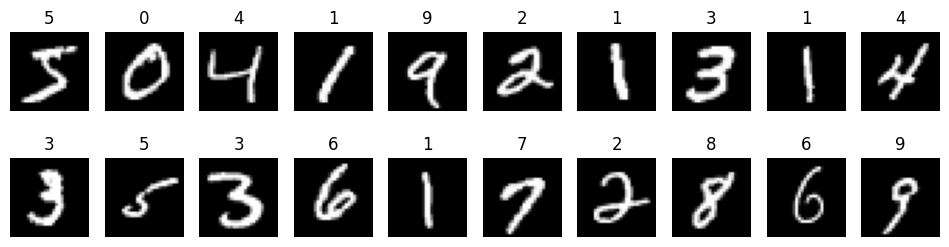

In [5]:
fig, assi = plt.subplots(2, 10, figsize=(12, 3))
for i, ax in enumerate(assi.flat):
    img, et = train_ds[i]
    ax.imshow(img[0], cmap="gray"); ax.set_title(et); ax.axis("off")
plt.show()

In [6]:
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=1000)
xb, yb = next(iter(train_dl))
print(xb.shape, yb.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


## 3.4 Il modello

In [7]:
fissa_seme(42)     # prima di costruire il modello: l'inizializzazione è casuale
modello = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
)
print(modello)
print("Parametri:", sum(p.numel() for p in modello.parameters()))
print(modello(xb).shape)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)
Parametri: 109386
torch.Size([64, 10])


## 3.5–3.6 Perdita, ottimizzatore, ciclo di addestramento

In [8]:
perdita_fn = nn.CrossEntropyLoss()
ottimizzatore = torch.optim.Adam(modello.parameters(), lr=1e-3)

def valuta(modello, dl):
    modello.eval()
    corretti, totale, perdita_tot = 0, 0, 0.0
    with torch.no_grad():
        for xb, yb in dl:
            uscita = modello(xb)
            perdita_tot += perdita_fn(uscita, yb).item() * len(yb)
            corretti += (uscita.argmax(dim=1) == yb).sum().item()
            totale += len(yb)
    return perdita_tot / totale, corretti / totale

In [9]:
storia = {"train": [], "test": [], "acc": []}
for epoca in range(5):
    modello.train()
    somma, n = 0.0, 0
    for xb, yb in train_dl:
        uscita = modello(xb)                  # 1. forward
        perdita = perdita_fn(uscita, yb)      # 2. perdita
        ottimizzatore.zero_grad()             # 3. azzera i gradienti
        perdita.backward()                    # 4. backward
        ottimizzatore.step()                  # 5. aggiorna i pesi
        somma += perdita.item() * len(yb); n += len(yb)
    perdita_test, acc_test = valuta(modello, test_dl)
    storia["train"].append(somma / n); storia["test"].append(perdita_test); storia["acc"].append(acc_test)
    print(f"Epoca {epoca+1}: perdita train {somma/n:.4f} | perdita test {perdita_test:.4f} | accuratezza test {acc_test:.2%}")

Epoca 1: perdita train 0.3330 | perdita test 0.1749 | accuratezza test 94.82%


Epoca 2: perdita train 0.1362 | perdita test 0.1100 | accuratezza test 96.51%


Epoca 3: perdita train 0.0945 | perdita test 0.0981 | accuratezza test 96.78%


Epoca 4: perdita train 0.0711 | perdita test 0.0949 | accuratezza test 97.13%


Epoca 5: perdita train 0.0546 | perdita test 0.0811 | accuratezza test 97.49%


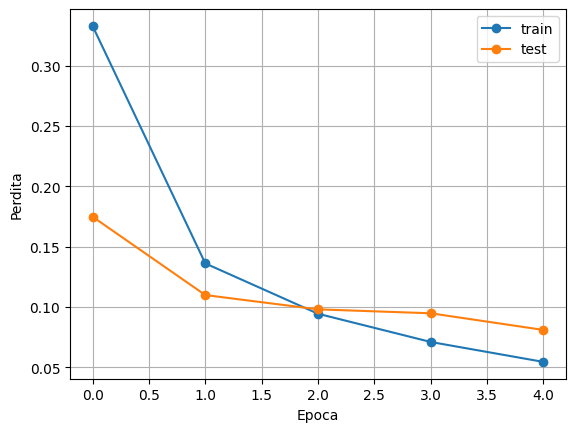

In [10]:
plt.plot(storia["train"], marker="o", label="train"); plt.plot(storia["test"], marker="o", label="test")
plt.xlabel("Epoca"); plt.ylabel("Perdita"); plt.legend(); plt.grid(True); plt.show()

## 3.7 Usare il modello

In [11]:
img, etichetta = test_ds[0]
modello.eval()
with torch.no_grad():
    logit = modello(img.unsqueeze(0))
    prob = torch.softmax(logit, dim=1)
print("Vera:", etichetta, "Prevista:", logit.argmax().item())
print("Probabilità:", torch.round(prob, decimals=3))

Vera: 7 Prevista: 7
Probabilità: tensor([[0.0000, 0.0000, 0.0000, 0.0030, 0.0000, 0.0000, 0.0000, 0.9960, 0.0000,
         0.0000]])


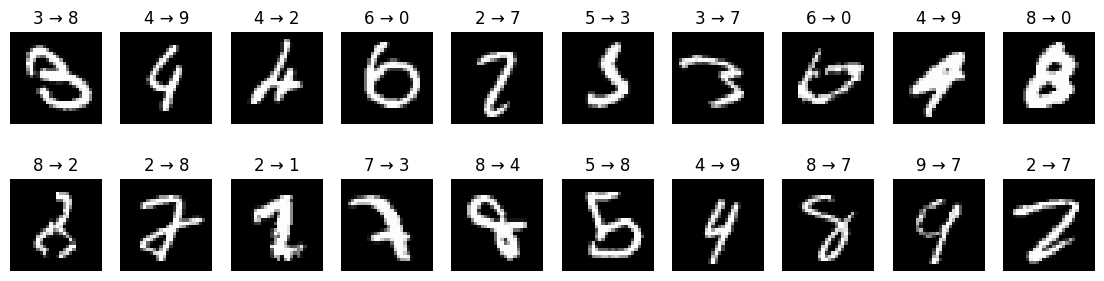

In [12]:
# I primi errori del test set
errori = []
with torch.no_grad():
    for xb, yb in test_dl:
        pred = modello(xb).argmax(dim=1)
        for i in torch.nonzero(pred != yb).flatten():
            errori.append((xb[i, 0], yb[i].item(), pred[i].item()))
        if len(errori) >= 20: break
fig, assi = plt.subplots(2, 10, figsize=(14, 3.5))
for (img, vera, prev), ax in zip(errori, assi.flat):
    ax.imshow(img, cmap="gray"); ax.set_title(f"{vera} → {prev}"); ax.axis("off")
plt.show()

In [13]:
from collections import Counter
confusioni = Counter()
with torch.no_grad():
    for xb, yb in test_dl:
        pred = modello(xb).argmax(dim=1)
        for a, b in zip(yb.tolist(), pred.tolist()):
            if a != b: confusioni[(a, b)] += 1
print("Coppie (vera, prevista) più frequenti:", confusioni.most_common(6))

Coppie (vera, prevista) più frequenti: [((4, 9), 14), ((8, 3), 14), ((5, 3), 11), ((9, 4), 10), ((6, 0), 9), ((8, 0), 9)]


## 3.8 Esperimenti
Una funzione per addestrare varianti; provare senza ReLU, con SGD, con altri `lr` e `batch_size`.

In [14]:
def esperimento(modello, ottimizzatore, epoche=5, batch_size=64):
    dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    for epoca in range(epoche):
        modello.train()
        for xb, yb in dl:
            perdita = perdita_fn(modello(xb), yb)
            ottimizzatore.zero_grad(); perdita.backward(); ottimizzatore.step()
    return valuta(modello, test_dl)[1]

fissa_seme(42)
senza_relu = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.Linear(128, 64), nn.Linear(64, 10))
print("Senza ReLU:", f"{esperimento(senza_relu, torch.optim.Adam(senza_relu.parameters(), lr=1e-3)):.2%}")

Senza ReLU: 91.70%
